In [1]:
import pandas as pd



In [2]:
df = pd.read_csv('./titanic_large.csv' , on_bad_lines='skip')



In [3]:
# The volume of the dataset:
! ls lh
### -rwxrwxrwx 1 melika melika 5.8M Aug 27 21:20  titanic_large.csv



'ls' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
## Initial Data Exploration:
print(df.head())
print(df.shape)
print(df.info())



   PassengerId  Survived  Pclass                      Name     Sex   Age  \
0        75722         0       3  Robinson, Master. Steven    male  55.6   
1        80185         1       2   Wilson, Master. Richard    male  85.0   
2        19865         1       2         Taylor, Ms. Betty  female   NaN   
3        76700         1       3     Smith, Mrs. Elizabeth  female  13.3   
4        92992         0       1      Jackson, Rev. Daniel    male  55.9   

   SibSp  Parch  Ticket   Fare Embarked  
0      2      3  600542   3.02        Q  
1      1      0  561216   8.68        S  
2      0      0  589751   4.61        S  
3      0      0   96366   5.56        S  
4      0      1  416388  40.64        S  
(100000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   PassengerId  100000 non-null  int64  
 1   Survived     100000 non-null  int64  
 2   Pc

In [5]:
## Numerical  Features Analysis
df_numeric=df[['Age','SibSp','Parch','Fare']]
print(df_numeric.describe())


                Age          SibSp          Parch           Fare
count  80144.000000  100000.000000  100000.000000  100000.000000
mean      31.731833       0.601000       0.398230      16.437273
std       18.985651       0.776315       0.631036      23.823469
min        0.400000       0.000000       0.000000       0.000000
25%       16.100000       0.000000       0.000000       3.970000
50%       30.800000       0.000000       0.000000       7.500000
75%       44.225000       1.000000       1.000000      17.950000
max       85.000000       6.000000       6.000000     348.910000


In [6]:
## Missing values Identification
print(df.isnull().sum())



PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age            19856
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
dtype: int64


In [7]:
## Zero Fare Inspection  (Free Ticket)
print(df[df['Fare']==0]['Fare'].value_counts())



Fare
0.0    500
Name: count, dtype: int64


In [8]:

## Age and fare Distribution
print(df['Age'].value_counts())
print(df['Fare'].value_counts())


Age
0.4     1223
85.0     516
9.7      194
35.5     190
37.1     189
        ... 
83.2       5
84.0       5
84.2       4
84.5       4
84.8       4
Name: count, Length: 847, dtype: int64
Fare
0.00      500
1.69      154
1.67      149
2.02      146
1.71      145
         ... 
229.63      1
239.92      1
104.99      1
132.02      1
165.76      1
Name: count, Length: 9515, dtype: int64


Matplotlib is building the font cache; this may take a moment.


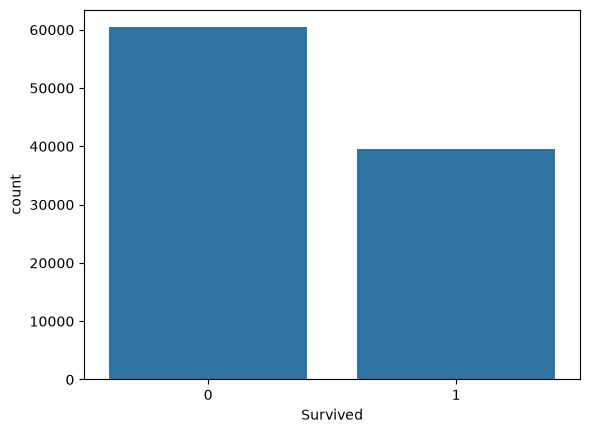

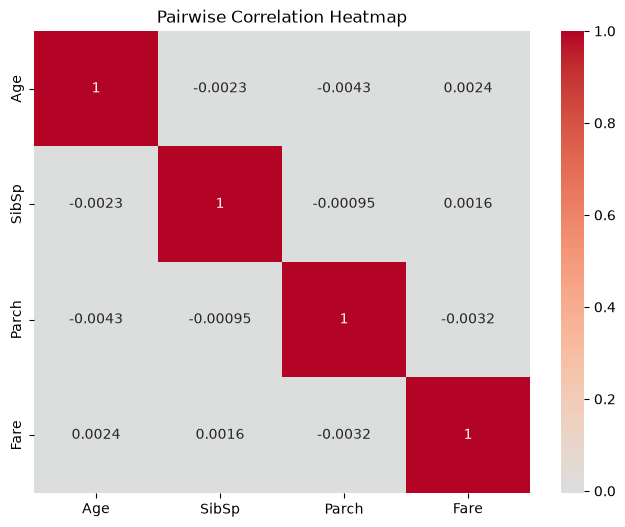

In [9]:
## data visualization and distribution

import seaborn as sns
import matplotlib.pyplot as plt

# Count of passengers who survive vs who did not survive
sns.countplot(x='Survived', data=df )
plt.show()

# Analyze linear Relationships between numerical features
corr = df_numeric.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Pairwise Correlation Heatmap")
plt.show()


In [10]:
## Analysis Factors for survival

## Number of people in each class
df_j=df.groupby('Pclass')['Survived'].count()
print("df_j:",df_j)

## Number of survived and unservived people in each class
df_j2=df.groupby(['Pclass','Survived'])['Age'].count()
print("conunt2",df_j2)

## detecting Null in Age
df_j3=df.groupby(['Pclass','Survived'])['Age'].size()
print("size2:",df_j3)

## calculating mean Age for each class for filling NaN
df_j4=df.groupby(['Pclass','Survived'])['Age'].mean()
print("size2:",df_j4)

## calculating mean survived people in each class
## it shows class is important factor for survival
df_j5=df.groupby('Pclass')['Survived'].mean()
print("size2:",df_j5)

## calculating Count based on  sex in each class and survival
## it shows women survive more than men ( against my initial Hypothesis)
df_j6=df.groupby(['Pclass','Survived'])['Sex'].value_counts()
print("size2:",df_j6)

## calculating mean based on sex in each class and survival
## it shows women survive more than men ( against my initial Hypothesis)
df_j7=df.groupby(['Pclass','Survived'])['Sex'].value_counts(normalize=True)
print("size2:",df_j7)



df_j: Pclass
1    19961
2    25132
3    54907
Name: Survived, dtype: int64
conunt2 Pclass  Survived
1       0            7234
        1            8805
2       0           11992
        1            8179
3       0           28720
        1           15214
Name: Age, dtype: int64
size2: Pclass  Survived
1       0            9158
        1           10803
2       0           15057
        1           10075
3       0           36166
        1           18741
Name: Age, dtype: int64
size2: Pclass  Survived
1       0           33.456124
        1           30.522703
2       0           33.389877
        1           29.735677
3       0           32.714060
        1           29.523774
Name: Age, dtype: float64
size2: Pclass
1    0.541205
2    0.400883
3    0.341323
Name: Survived, dtype: float64
size2: Pclass  Survived  Sex   
1       0         male       6724
                  female     2434
        1         female     5556
                  male       5247
2       0         male      106

In [11]:
## Summary analysis
df_summary = df.groupby(['Pclass', 'Sex']).agg({
    'Age': ['min', 'max', 'mean'],
    'Fare': 'mean',
    'Survived': 'mean'
})

print(df_summary)
## More Analyzing After equality (Min / Max) Age in each group
print(df[df['Age']==0.4]['Pclass'].value_counts())
print(df[df['Age']==85.00]['Pclass'].value_counts())


               Age                        Fare  Survived
               min   max       mean       mean      mean
Pclass Sex                                              
1      female  0.4  85.0  31.978385  48.840190  0.695369
       male    0.4  85.0  31.756766  49.859752  0.438309
2      female  0.4  85.0  31.634797  13.972153  0.563258
       male    0.4  85.0  32.085952  13.960447  0.293881
3      female  0.4  85.0  31.446892   5.527935  0.488359
       male    0.4  85.0  31.717188   5.592308  0.244356
Pclass
3    684
2    329
1    210
Name: count, dtype: int64
Pclass
3    274
2    142
1    100
Name: count, dtype: int64


In [12]:
## filling Nan in Age
import numpy as np
df_mean=df.groupby('Pclass')['Age'].mean()
print(df_mean)

conditions=[
    ((df['Age'].isnull()) & (df['Pclass']==3)),
    ((df['Age'].isnull()) & (df['Pclass']==2)),
    ((df['Age'].isnull()) & (df['Pclass']==1))
]

choices = [31,32,32]

df['Age'] = np.select(conditions, choices, default=df["Age"])


Pclass
1    31.845751
2    31.908160
3    31.609289
Name: Age, dtype: float64


In [13]:
#df.loc[(df['Age'].isnull()) & (df['Pclass']==3),'Age']=32


In [14]:
## Calculating Categorical Age Column
df['Age_category']=pd.cut(df['Age'], labels=['child','Young','adults','middle_age', 'old'],bins=[0.4,10,20,40,60,85])
print(df['Age_category'].head(5))


0    middle_age
1           old
2        adults
3         Young
4    middle_age
Name: Age_category, dtype: category
Categories (5, str): ['child' < 'Young' < 'adults' < 'middle_age' < 'old']


In [15]:
## Analyzing Age Factor in survival
df_Ca=df.groupby('Age_category')['Survived'].mean()
print(df_Ca)


Age_category
child         0.514036
Young         0.410626
adults        0.377389
middle_age    0.378482
old           0.343856
Name: Survived, dtype: float64


In [16]:
## Analyzing status family on survival
dfs=df['SibSp'].value_counts()
print(dfs.head())

df_p=df['Parch'].value_counts()
print(df_p)


## initial Analysis  family Factor in survival
df_Sp=df.groupby('SibSp')['Survived'].mean()
print(df_Sp)
df_p2=df.groupby('Parch')['Survived'].mean().sort_values(ascending=False)
print(df_p2)


##  Calculating Family Size  Column and its effect on Survival
df['familysize']=df['SibSp']+df['Parch']+1
df_s=df['familysize'].value_counts()
print(df_s)
df_p2=df.groupby('familysize')['Survived'].mean().sort_values(ascending=False)
print(df_p2)

df['family_status']=pd.cut(df['familysize'],bins=[0,1 ,3, 6, 9],labels=['alone','small','medium','big'])
df_p22 = df.groupby('family_status')['Survived'].agg(['mean', 'std', 'count']).sort_values(by='mean', ascending=False)
print(df_p22)
## Narrow gap between means lead to calculate SE
import numpy as np
df_p22['SE']=df_p22['std']/np.sqrt(df_p22['count'])
df_p22['ci_lower'] = df_p22['mean'] - (1.96 * df_p22['SE'])
df_p22['ci_upper'] = df_p22['mean'] + (1.96 * df_p22['SE'])

print(df_p22[['mean', 'SE', 'ci_lower', 'ci_upper']])



SibSp
0    54858
1    32920
2     9882
3     1992
4      305
Name: count, dtype: int64
Parch
0    67108
1    26839
2     5283
3      671
4       92
5        5
6        2
Name: count, dtype: int64
SibSp
0    0.409238
1    0.386695
2    0.368346
3    0.343373
4    0.340984
5    0.263158
6    0.200000
Name: Survived, dtype: float64
Parch
4    0.576087
2    0.409616
3    0.408346
1    0.407802
5    0.400000
0    0.390132
6    0.000000
Name: Survived, dtype: float64
familysize
2    36863
1    36793
3    18317
4     6121
5     1540
6      305
7       50
8       10
9        1
Name: count, dtype: int64
familysize
8    0.500000
1    0.402767
2    0.397445
3    0.388273
4    0.380493
5    0.375974
7    0.360000
6    0.347541
9    0.000000
Name: Survived, dtype: float64
                   mean       std  count
family_status                           
alone          0.402767  0.490461  36793
small          0.394400  0.488726  55180
medium         0.378358  0.485008   7966
big            0.377049  

In [17]:
## cleaning Name Column

df[['lastname','firstname']]=df['Name'].str.split(',',expand=True)
print(df)
df=df.drop(columns=['Name'])
df[['title','firstname']]=df['firstname'].str.split('.',expand=True)
df.drop(columns=['title'])


       PassengerId  Survived  Pclass                      Name     Sex   Age  \
0            75722         0       3  Robinson, Master. Steven    male  55.6   
1            80185         1       2   Wilson, Master. Richard    male  85.0   
2            19865         1       2         Taylor, Ms. Betty  female  32.0   
3            76700         1       3     Smith, Mrs. Elizabeth  female  13.3   
4            92992         0       1      Jackson, Rev. Daniel    male  55.9   
...            ...       ...     ...                       ...     ...   ...   
99995         6266         0       3      Robinson, Rev. James    male  32.0   
99996        54887         0       3       Jackson, Mr. Donald    male  25.5   
99997        76821         0       2       Wilson, Rev. Donald    male  32.0   
99998          861         0       3      Robinson, Mr. Donald    male  32.8   
99999        15796         1       1      Wilson, Dr. Jennifer  female  27.0   

       SibSp  Parch  Ticket   Fare Emba

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_category,familysize,family_status,lastname,firstname
0,75722,0,3,male,55.6,2,3,600542,3.02,Q,middle_age,6,medium,Robinson,Steven
1,80185,1,2,male,85.0,1,0,561216,8.68,S,old,2,small,Wilson,Richard
2,19865,1,2,female,32.0,0,0,589751,4.61,S,adults,1,alone,Taylor,Betty
3,76700,1,3,female,13.3,0,0,96366,5.56,S,Young,1,alone,Smith,Elizabeth
4,92992,0,1,male,55.9,0,1,416388,40.64,S,middle_age,2,small,Jackson,Daniel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,0,3,male,32.0,1,1,219100,2.53,S,adults,3,small,Robinson,James
99996,54887,0,3,male,25.5,0,0,403270,17.17,S,adults,1,alone,Jackson,Donald
99997,76821,0,2,male,32.0,1,0,345632,12.25,S,adults,2,small,Wilson,Donald
99998,861,0,3,male,32.8,0,1,798295,6.16,C,adults,2,small,Robinson,Donald
